In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from scipy.signal import savgol_filter
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings("ignore")

## EDA

In [2]:
df_numerical = pd.read_csv("data/numerical_data.csv", index_col=0, parse_dates=True)

In [3]:
df_sentiment = pd.read_csv("data/sentiment_data.csv", index_col=0, parse_dates=True)

In [4]:
df_sentiment = df_sentiment.set_index('date')

In [5]:
# Check the index types of both dataframes
print(df_numerical.index.dtype)
print(df_sentiment.index.dtype)

# Check how dates look in both
print(df_numerical.index[:3])
print(df_sentiment.index[:3])

datetime64[ns]
object
DatetimeIndex(['2006-01-03', '2006-01-04', '2006-01-05'], dtype='datetime64[ns]', freq=None)
Index(['2006-01-01', '2006-01-03', '2006-01-04'], dtype='object', name='date')


In [6]:
df_sentiment.index = pd.to_datetime(df_sentiment.index)
df_numerical.index = pd.to_datetime(df_numerical.index)

In [7]:
print(df_sentiment.index.dtype)

datetime64[ns]


In [8]:
df = df_numerical.join(df_sentiment, how='left')
df.sort_index(inplace=True)

print(df_numerical.shape)
print(df_sentiment.shape)
print(df.shape)

(5075, 10)
(5249, 1)
(5075, 11)


In [9]:
df

,Gold,DXY,Real_Yield_10Y,Breakeven_10Y,Fed_Funds,WTI_Oil,SP500,VIX,CPI_YoY,M2_YoY,sentiment
2006-01-03,530.700012,100.7558,2.03,2.34,4.34,63.11,1268.800049,11.14,3.338550,3.971091,0.170425
2006-01-04,533.900024,100.2288,2.01,2.35,4.22,63.41,1273.459961,11.37,3.338550,3.971091,0.031700
2006-01-05,526.299988,100.2992,2.04,2.32,4.24,62.81,1273.479980,11.31,3.338550,3.971091,0.356600
2006-01-06,539.700012,100.0241,2.05,2.33,4.22,64.21,1285.449951,11.00,3.338550,3.971091,0.174800
2006-01-09,549.099976,100.1794,2.05,2.33,4.25,63.56,1290.150024,11.13,3.338550,3.971091,0.690050
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,5107.399902,119.4341,1.77,2.29,3.64,71.13,6816.629883,23.57,2.653304,4.230511,-0.177500
2026-03-04,5120.200195,119.0705,1.80,2.29,3.64,71.13,6869.500000,21.15,2.653304,4.230511,0.041367
2026-03-05,5065.299805,119.5683,1.82,2.31,3.64,71.13,6830.709961,23.75,2.653304,4.230511,-0.186700
2026-03-06,5146.100098,119.4910,1.80,2.35,3.64,71.13,6740.020020,29.49,2.653304,4.230511,-0.130592


In [10]:
df = df.ffill()

In [11]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
sentiment         0
dtype: int64

In [12]:
df["log_price"] = np.log(df["Gold"])
df["t"] = np.arange(len(df))

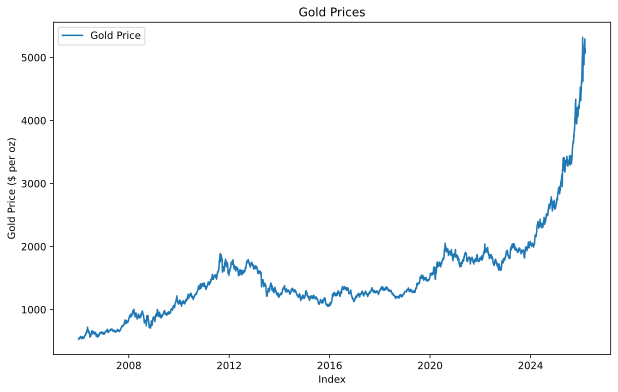

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df["Gold"], label="Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Gold Price ($ per oz)")
plt.title("Gold Prices")
plt.legend()
plt.savefig("results/p1_gold", bbox_inches="tight")
plt.show()

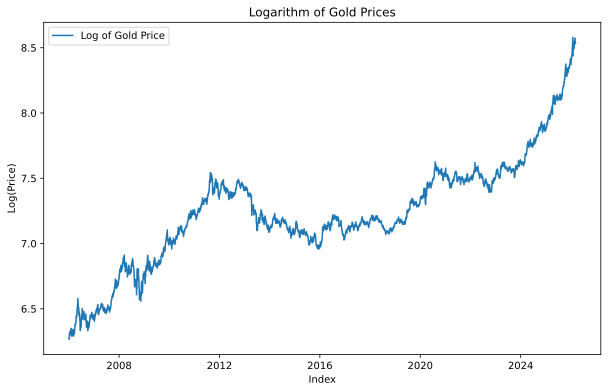

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(df["log_price"], label="Log of Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Log(Price)")
plt.title("Logarithm of Gold Prices")
plt.legend()
plt.savefig("results/p1_log_gold", bbox_inches="tight")
plt.show()

## Baseline model to predict next day gold price

## Auto Arima

In [15]:
# Use a large training period, e.g., last 5–10 years
residuals = df["log_price"] - LinearRegression().fit(df[["t"]], df["log_price"]).predict(df[["t"]])

tuned_model = auto_arima(
    residuals,
    stationary=True,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=10,
    max_q=10,
    max_d=0,
    trace = True,
    n_jobs=-1
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-30827.344, Time=1.67 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-976.022, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-7661.355, Time=1.47 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-978.022, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-30826.507, Time=0.94 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.92 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=-30826.741, Time=1.39 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=4.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-30825.087, Time=0.63 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-30825.815, Time=1.96 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-30825.869, Time=0.79 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=-30822.414, Time=4.99 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-30829.268, Time=0.54 sec
 ARIMA(1,0,2)(0,0,0)[0]        

In [16]:
# Save best hyperparameters
p, d, q = tuned_model.order
print("Selected ARIMA order:", (p,d,q))
print("AIC:", tuned_model.aic())

Selected ARIMA order: (2, 0, 2)
AIC: -30829.267873512254


In [17]:
forecast_horizon = 325
start_index = len(df) - forecast_horizon - 1
WINDOW = 252*15

def fit_linear_trend(train_data):
    """Fit a linear trend model to log_price and return model + residuals."""
    X_trend = train_data[["t"]]
    y_trend = train_data["log_price"]

    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)

    train_data = train_data.copy()
    train_data["trend"] = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]

    return trend_model, train_data


def fit_arma_residual(train_data, p, d, q):
    """Fit an ARIMA model to the residuals and return the fitted model."""
    arma_model = ARIMA(train_data["residual"], order=(p, d, q))
    return arma_model.fit()


def forecast_next_day(trend_model, arma_fitted, last_t):
    """Forecast the next day's gold price using trend + ARMA residual."""
    next_t = np.array([[last_t + 1]])
    trend_forecast = trend_model.predict(next_t)[0]
    residual_forecast = arma_fitted.forecast(steps=1).iloc[0]

    log_price_forecast = trend_forecast + residual_forecast
    return np.exp(log_price_forecast)


def run_rolling_forecast(df, start_index, p, d, q, window=WINDOW):
    """
    Run a rolling window forecast over the dataframe.
    Training data is capped to the last `window` days at each step.

    Returns:
        dates, predictions, actuals — aligned lists for evaluation.
    """
    predictions, actuals, dates = [], [], []
    total = len(df) - start_index - 1

    for i in range(start_index, len(df) - 1):
        percent_complete = (i - start_index + 1) / total * 100
        print(f"\rProgress: {percent_complete:.2f}%", end="")

        train_data = df.iloc[max(0, i - window + 1):i + 1]  # last `window` days only

        trend_model, train_data = fit_linear_trend(train_data)
        arma_fitted = fit_arma_residual(train_data, p, d, q)
        price_forecast = forecast_next_day(trend_model, arma_fitted, train_data["t"].iloc[-1])

        predictions.append(price_forecast)
        actuals.append(df["Gold"].iloc[i + 1])
        dates.append(df.index[i + 1])

    print("\nDone!")
    return dates, predictions, actuals


# --- Usage ---
dates, predictions, actuals = run_rolling_forecast(df, start_index, p, d, q)

Progress: 100.00%
Done!


In [18]:
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")

In [19]:
results_2025 = results[results.index.year == 2025]
mape_2025 = (np.abs((results_2025["Actual"] - results_2025["Predicted"]) / results_2025["Actual"]).mean()) * 100
print(f"MAPE 2025: {mape_2025:.2f}%")

MAPE 2025: 0.96%


In [20]:
results_252 = results.iloc[-252:]
mape_252 = (np.abs((results_252["Actual"] - results_252["Predicted"]) / results_252["Actual"]).mean()) * 100
print(f"MAPE (Last 252 Trading Days): {mape_252:.2f}%")

MAPE (Last 252 Trading Days): 1.15%


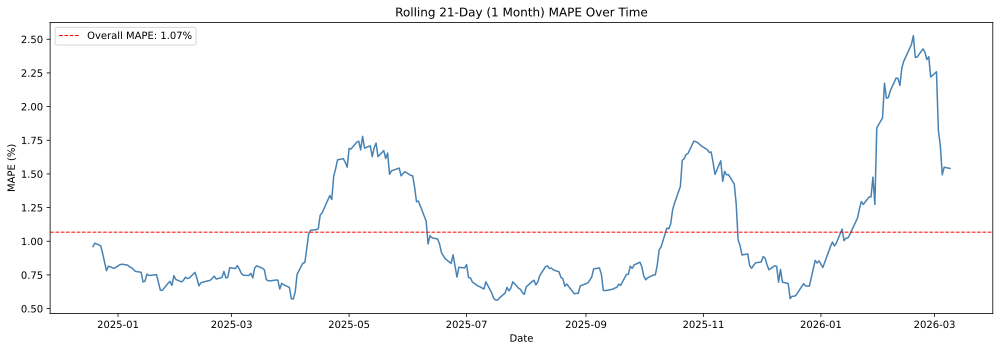

In [21]:
results["APE"] = np.abs((results["Actual"] - results["Predicted"]) / results["Actual"]) * 100
results["Rolling_MAPE"] = results["APE"].rolling(window=21).mean()  # 21 trading days ≈ 1 month

plt.figure(figsize=(14, 5))
plt.plot(results.index, results["Rolling_MAPE"], color="steelblue", linewidth=1.5)
plt.axhline(results["APE"].mean(), color="red", linestyle="--", linewidth=1, label=f'Overall MAPE: {results["APE"].mean():.2f}%')
plt.title("Rolling 21-Day (1 Month) MAPE Over Time")
plt.xlabel("Date")
plt.ylabel("MAPE (%)")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_rolling_mape", bbox_inches="tight")
plt.show()

In [22]:
def directional_accuracy(df):
    actual_dir = np.sign(df["Actual"].diff())
    predicted_dir = np.sign(df["Predicted"].diff())
    return (actual_dir == predicted_dir).mean() * 100

da_2025 = directional_accuracy(results_2025)
da_252 = directional_accuracy(results_252)

print(f"Directional Accuracy 2025:            {da_2025:.2f}%")
print(f"Directional Accuracy Last 252 Days:   {da_252:.2f}%")

Directional Accuracy 2025:            43.25%
Directional Accuracy Last 252 Days:   42.46%


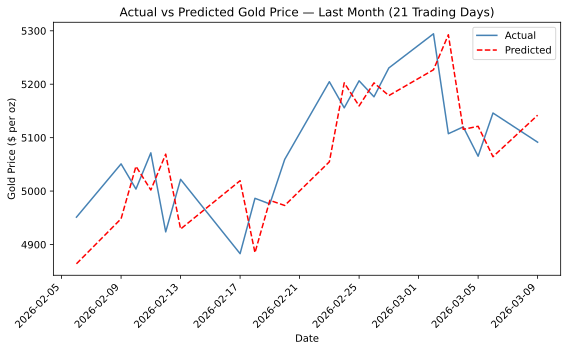

In [23]:
results_last_month = results.iloc[-21:]

plt.figure(figsize=(8, 5))
plt.plot(results_last_month.index, results_last_month["Actual"], color="steelblue", linewidth=1.5, label="Actual")
plt.plot(results_last_month.index, results_last_month["Predicted"], color="red", linewidth=1.5, linestyle="--", label="Predicted")
plt.title("Actual vs Predicted Gold Price — Last Month (21 Trading Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price ($ per oz)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_last_month_forecast_base", bbox_inches="tight")
plt.show()

## Simple XGBoost

In [35]:
df = df.drop(['log_price', 't'], axis = 1)

In [36]:
df

,Gold,DXY,Real_Yield_10Y,Breakeven_10Y,Fed_Funds,WTI_Oil,SP500,VIX,CPI_YoY,M2_YoY,sentiment
2006-01-03,530.700012,100.7558,2.03,2.34,4.34,63.11,1268.800049,11.14,3.338550,3.971091,0.170425
2006-01-04,533.900024,100.2288,2.01,2.35,4.22,63.41,1273.459961,11.37,3.338550,3.971091,0.031700
2006-01-05,526.299988,100.2992,2.04,2.32,4.24,62.81,1273.479980,11.31,3.338550,3.971091,0.356600
2006-01-06,539.700012,100.0241,2.05,2.33,4.22,64.21,1285.449951,11.00,3.338550,3.971091,0.174800
2006-01-09,549.099976,100.1794,2.05,2.33,4.25,63.56,1290.150024,11.13,3.338550,3.971091,0.690050
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,5107.399902,119.4341,1.77,2.29,3.64,71.13,6816.629883,23.57,2.653304,4.230511,-0.177500
2026-03-04,5120.200195,119.0705,1.80,2.29,3.64,71.13,6869.500000,21.15,2.653304,4.230511,0.041367
2026-03-05,5065.299805,119.5683,1.82,2.31,3.64,71.13,6830.709961,23.75,2.653304,4.230511,-0.186700
2026-03-06,5146.100098,119.4910,1.80,2.35,3.64,71.13,6740.020020,29.49,2.653304,4.230511,-0.130592


In [42]:
TARGET_COL   = "Gold"
EXOG_VARS  = [col for col in df.columns if col != TARGET_COL]
GOLD_LAGS    = [1, 2, 3, 5, 10, 20]
EXOG_LAGS    = [1, 2, 5]
TRAIN_WINDOW = 252 * 15   # 3780 trading days
TEST_WINDOW  = 325        # last 325 trading days

XGB_PARAMS = dict(
    n_estimators    = 800,
    max_depth       = 4,
    learning_rate   = 0.01,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1,
    random_state    = 42
)

In [45]:
# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
def build_features(df):
    """Build all features exactly as specified."""
    df = df.copy()

    # Next day target
    df["target"] = df[TARGET_COL].shift(-1)

    # Gold lags
    for lag in GOLD_LAGS:
        df[f"gold_lag_{lag}"] = df[TARGET_COL].shift(lag)

    # Exogenous lags
    for col in EXOG_VARS:
        for lag in EXOG_LAGS:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

    return df

# ── 2. ROLLING FORECAST (REFACTORED) ─────────────────────────────────────────

def validate_data(df_feat, train_window, test_window):
    """Validate enough data exists for the rolling forecast."""
    total_required = train_window + test_window
    if len(df_feat) < total_required:
        raise ValueError(f"Need {total_required} rows after feature engineering, got {len(df_feat)}")
    return df_feat.iloc[-(train_window + test_window):]


def get_window_split(df_feat, i, train_window):
    """Slice and split a single rolling window into train and latest row."""
    window     = df_feat.iloc[i : i + train_window + 1].copy()
    latest_row = window.iloc[-1:].copy()
    train_df   = window.iloc[:-1].dropna()
    return train_df, latest_row


def get_X_y(train_df):
    """Split training window into features and target."""
    X_train = train_df.drop("target", axis=1)
    y_train = train_df["target"]
    return X_train, y_train


def train_model(X_train, y_train):
    """Train an XGBRegressor on the given data."""
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, verbose=False)
    return model


def predict_next_day(model, latest_row, X_train):
    """Generate next day prediction from the latest row."""
    latest_features = latest_row.drop("target", axis=1)
    latest_features = latest_features[X_train.columns]    # ensure column order
    return model.predict(latest_features)[0]


def run_single_step(df_feat, i, train_window):
    """Run a single rolling step: split → train → predict."""
    train_df, latest_row = get_window_split(df_feat, i, train_window)
    X_train, y_train     = get_X_y(train_df)
    model                = train_model(X_train, y_train)
    pred                 = predict_next_day(model, latest_row, X_train)
    return pred, model


def rolling_xgb_forecast(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW):
    """
    Rolling 1-step ahead XGBoost forecast.

    At each step i:
      - Train on rows [i : i + train_window - 1]  (train_window rows)
      - 'latest_row' is row [i + train_window - 1] (last row of window)
      - Predict target = row [i + train_window]    (true next day)
    """
    df_feat = build_features(df)
    df_feat = validate_data(df_feat, train_window, test_window)

    predictions, actuals, pred_dates = [], [], []

    print(f"Train window : {train_window} days")
    print(f"Test window  : {test_window} days")
    print(f"Rolling forecast started...\n")

    for i in range(test_window):

        pred, model = run_single_step(df_feat, i, train_window)

        predictions.append(pred)
        actuals.append(df_feat.iloc[i + train_window][TARGET_COL])
        pred_dates.append(df_feat.index[i + train_window])

        print(f"\r  Progress: {((i + 1) / test_window) * 100:.1f}%", end="", flush=True)

    return pred_dates, predictions, actuals, model

In [46]:
# ── 4. RUN ────────────────────────────────────────────────────────────────────
dates, predictions, actuals, model = rolling_xgb_forecast(df)

Train window : 3780 days
Test window  : 325 days
Rolling forecast started...

  Progress: 100.0%

In [48]:
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")

In [49]:
results_2025 = results[results.index.year == 2025]
mape_2025 = (np.abs((results_2025["Actual"] - results_2025["Predicted"]) / results_2025["Actual"]).mean()) * 100
print(f"MAPE 2025: {mape_2025:.2f}%")

MAPE 2025: 1.02%


In [50]:
results_252 = results.iloc[-252:]
mape_252 = (np.abs((results_252["Actual"] - results_252["Predicted"]) / results_252["Actual"]).mean()) * 100
print(f"MAPE (Last 252 Trading Days): {mape_252:.2f}%")

MAPE (Last 252 Trading Days): 1.16%


In [51]:
def directional_accuracy(df):
    actual_dir = np.sign(df["Actual"].diff())
    predicted_dir = np.sign(df["Predicted"].diff())
    return (actual_dir == predicted_dir).mean() * 100

da_2025 = directional_accuracy(results_2025)
da_252 = directional_accuracy(results_252)

print(f"Directional Accuracy 2025:            {da_2025:.2f}%")
print(f"Directional Accuracy Last 252 Days:   {da_252:.2f}%")

Directional Accuracy 2025:            70.24%
Directional Accuracy Last 252 Days:   68.25%


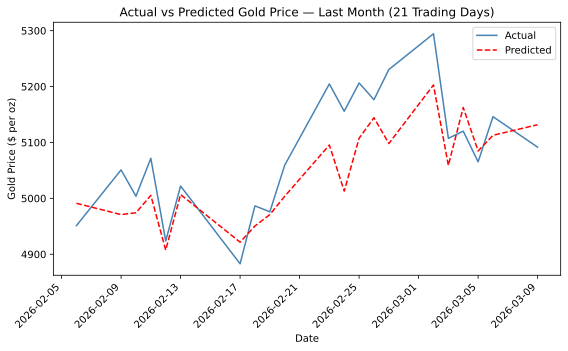

In [52]:
results_last_month = results.iloc[-21:]

plt.figure(figsize=(8, 5))
plt.plot(results_last_month.index, results_last_month["Actual"], color="steelblue", linewidth=1.5, label="Actual")
plt.plot(results_last_month.index, results_last_month["Predicted"], color="red", linewidth=1.5, linestyle="--", label="Predicted")
plt.title("Actual vs Predicted Gold Price — Last Month (21 Trading Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price ($ per oz)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_last_month_forecast_xg", bbox_inches="tight")
plt.show()